# Applications of AI

## Homework 3 - AI in Finance

### Marianna Kanellaki
### S-001081

TODO: summary

### Dataset Loading & Inspection

In [167]:
import pandas as pd

df = pd.read_csv('credit_risk_dataset.csv')
df


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


Detailed data description of Credit Risk dataset:

##Feature Name ## Description

#In finance, "default" means the borrower did not repay the loan as agreed — missed payments or stopped paying entirely.

loan_status 	Loan status (0 is non default 1 is default) # 1 means failed to repay the loan after being approved.

person_age 	Age

person_income 	Annual Income

person_home_ownership 	Home ownership

person_emp_length 	Employment length (in years)

loan_intent 	Loan intent

loan_grade 	Loan grade

loan_amnt 	Loan amount

loan_int_rate 	Interest rate

loan_percent_income 	Percent income

cb_person_default_on_file 	Historical default

cb_preson_cred_hist_length 	Credit history length

In [168]:
# Basic info
df.info()

# Summary statistics
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


The dataset contains 32,581 entries across 12 columns. It includes 8 numerical and 4 categorical variables. We have 2 columns that contain null values (person_emp_length and loan_int_rate). Finally, we have some weird data, for example a maximum age of 144 and an employment length of 123 years. Loan status is a bit unbalanced, with around 21% of applicants' loan status being 0.

### Data Cleaning & Preparation

In [169]:
# Count missing values in each column
df.isnull().sum()


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

#### Imputation of missing values with mean

In [170]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].mean())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())
df.isnull().sum()


person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

#### Categorical feature encoding

In [171]:
# Identify categorical features
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

/tmp/ipykernel_14787/2030784498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

In [172]:
# show Unique Classes in Each Categorical Column

for col in categorical_cols:
    print(f"{col} - {df[col].nunique()} unique classes")
    print(f"Classes: {df[col].unique()}\n")

person_home_ownership - 4 unique classes
Classes: <StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent - 6 unique classes
Classes: <StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

loan_grade - 7 unique classes
Classes: <StringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str

cb_person_default_on_file - 2 unique classes
Classes: <StringArray>
['Y', 'N']
Length: 2, dtype: str



In [173]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


One-hot encode

In [174]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30,False,False,...,False,True,False,False,True,False,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,19,False,False,...,False,True,False,False,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,28,False,False,...,False,False,False,True,False,False,False,False,False,False
32579,56,150000,5.0,15000,11.48,0,0.10,26,False,False,...,False,True,False,True,False,False,False,False,False,False


#### Numerical Feature Scaling

In [175]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'loan_status' in num_cols:
    num_cols.remove('loan_status')
    
num_cols

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

Scaling numerical features to ensure equal feature importance

In [176]:
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,-0.903374,-0.114143,28.935738,4.019404,1.625251,1,3.931411,-0.691554,False,False,...,False,True,False,False,False,True,False,False,False,True
1,-1.060904,-0.911147,0.051481,-1.358650,0.041636,0,-0.657458,-0.938167,False,True,...,False,False,False,True,False,False,False,False,False,False
2,-0.430783,-0.911147,-0.927646,-0.646849,0.603041,1,3.744110,-0.691554,False,False,...,True,False,False,False,True,False,False,False,False,False
3,-0.745843,-0.009274,-0.193301,4.019404,1.368887,1,3.369508,-0.938167,False,False,...,True,False,False,False,True,False,False,False,False,False
4,-0.588313,-0.188358,0.785826,4.019404,1.057357,1,3.556809,-0.444942,False,False,...,True,False,False,False,True,False,False,False,False,True


### Explorative Data Analysis

#### Univariate Analysis (Histograms)

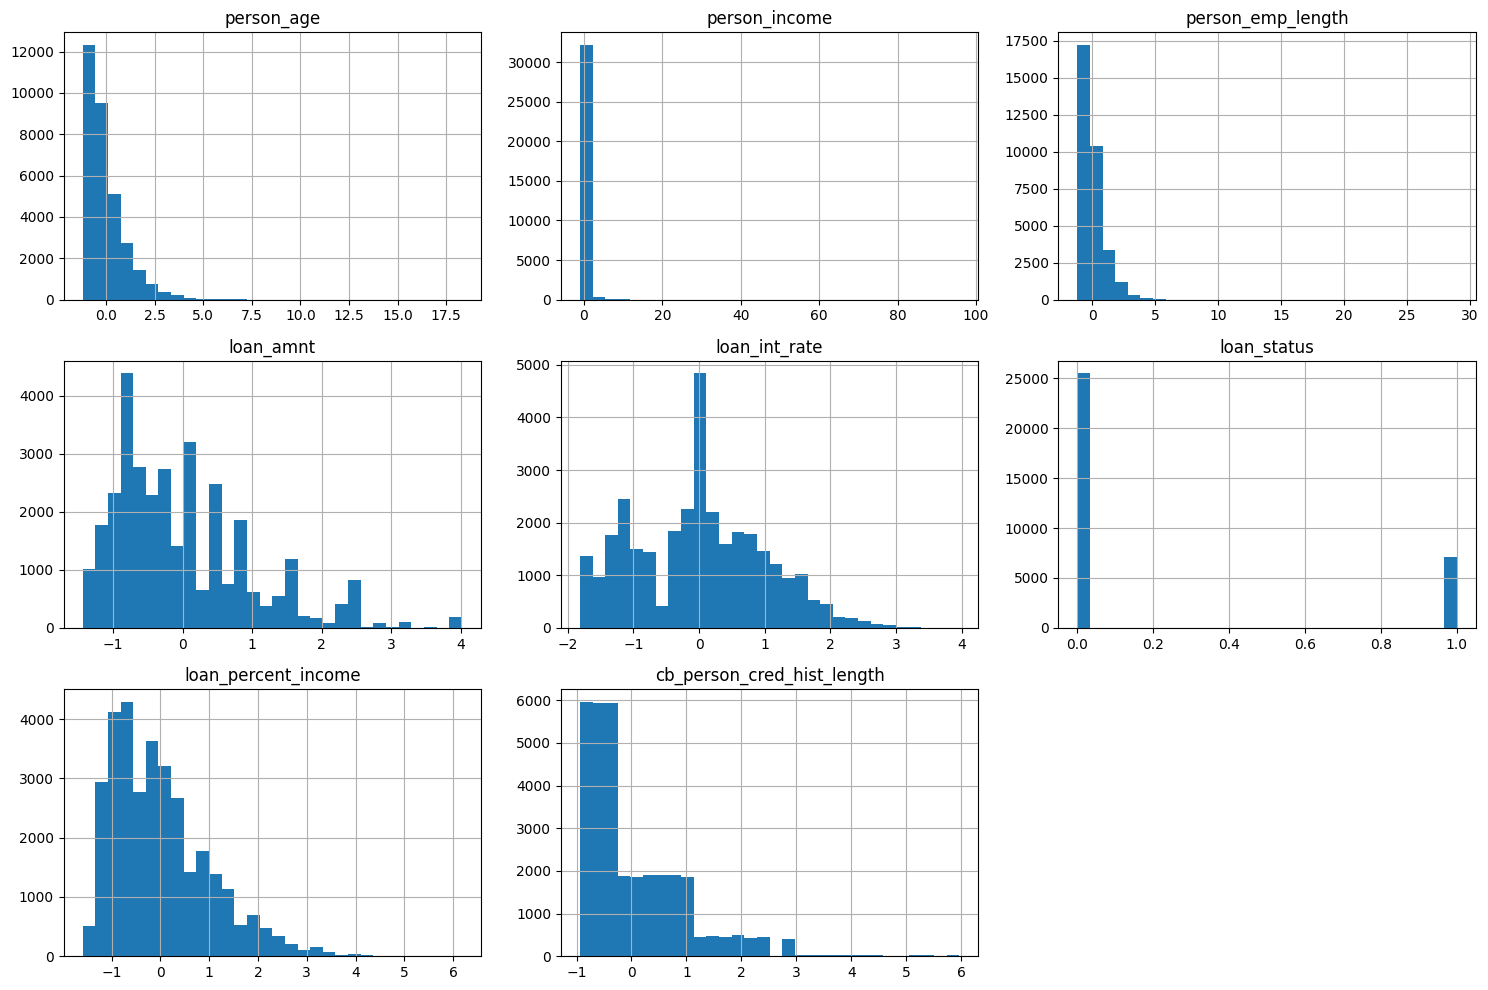

In [177]:
import matplotlib.pyplot as plt

df_encoded.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


#### Multivariate Analysis (Pair Plot & Boxplots)

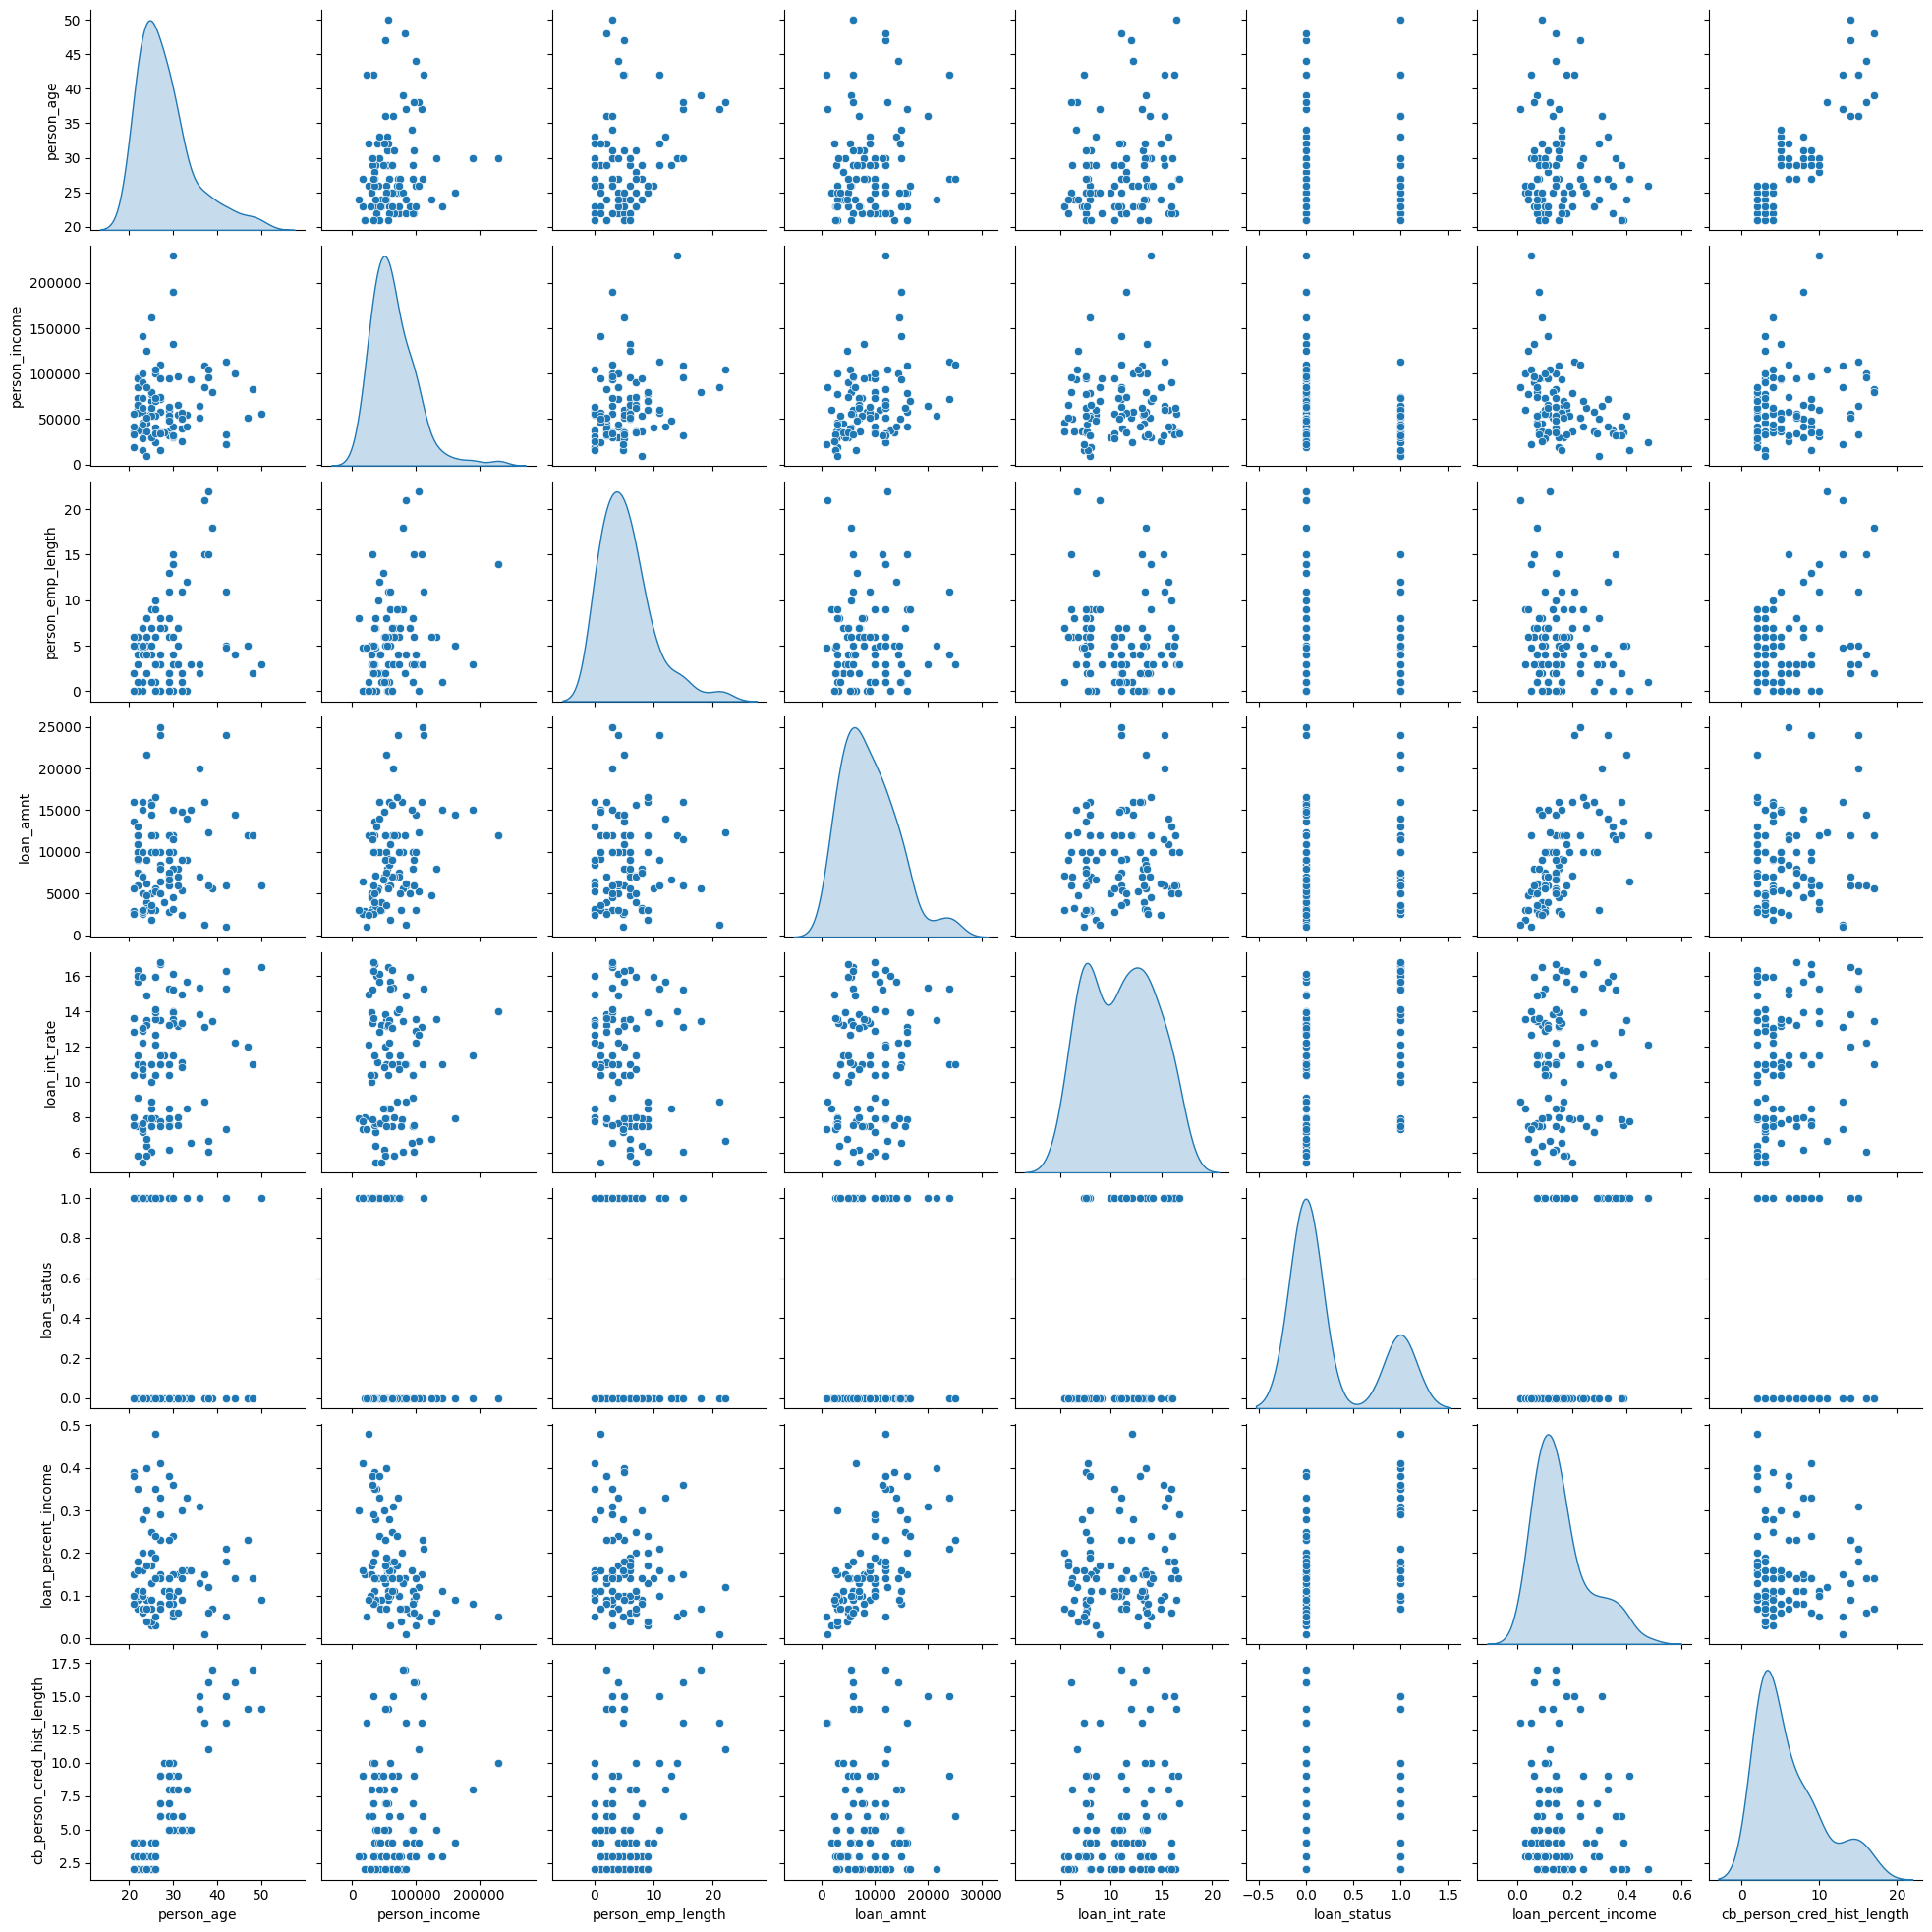

In [178]:
import seaborn as sns

# Pairplot on selected features for quick look
sns.pairplot(df.sample(100), diag_kind='kde')
plt.show()


### Correlation Analysis

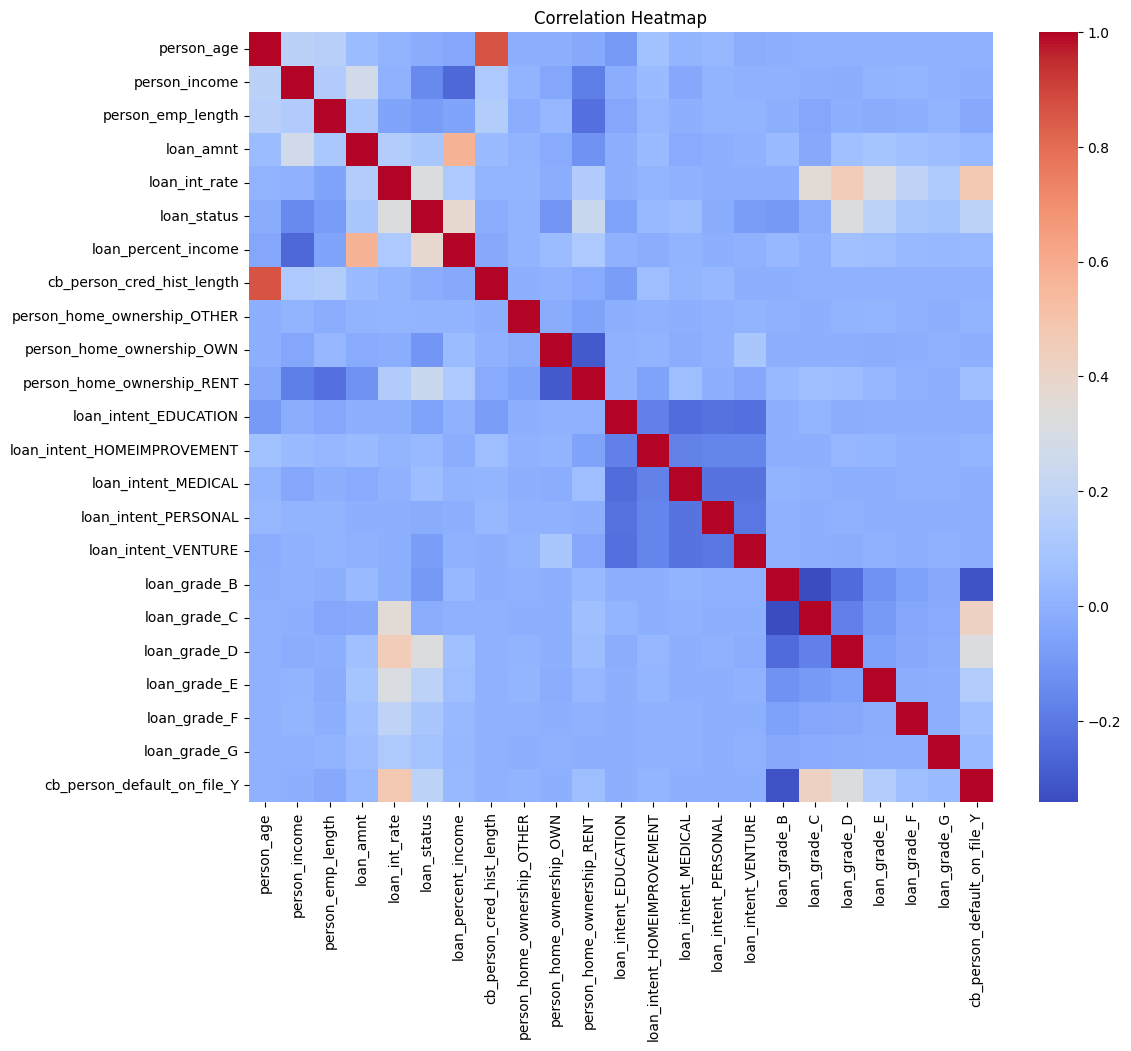

In [179]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [180]:
# Calculate correlation matrix
corr_matrix = df_encoded.corr()

# Get correlation with target variable
target_corr = corr_matrix['loan_status'].drop('loan_status')

# Rank top 5 features most positively or negatively correlated
top5_corr = target_corr.abs().sort_values(ascending=False).head(5)
print("Top 5 features most correlated with loan_status:\n")
print(top5_corr)


Top 5 features most correlated with loan_status:

loan_percent_income           0.379366
loan_int_rate                 0.319342
loan_grade_D                  0.318998
person_home_ownership_RENT    0.238430
loan_grade_E                  0.180122
Name: loan_status, dtype: float64


| Feature                      | Correlation | Explanation                                  |
| ---------------------------- | ----------- | -------------------------------------------- |
| `loan_percent_income`        | +0.38       | Higher financial burden → more risk          |
| `loan_int_rate`              | +0.32       | Risk-adjusted pricing reflects borrower risk |
| `loan_grade_D`               | +0.32       | Lower loan grade implies higher risk         |
| `person_home_ownership_RENT` | +0.24       | Renters may lack asset ownership             |
| `loan_grade_E`               | +0.18       | Even lower grade = even higher risk          |

#In finance, "default" means the borrower did not repay the loan as agreed — missed payments or stopped paying entirely.

loan_status 	Loan status (0 is non default 1 is default) # 1 means failed to repay the loan after being approved.


person_home_ownership 	Home ownership

loan_grade 	Loan grade

loan_int_rate 	Interest rate

1. loan_percent_income

This represents the percent of the applicant's income for the specific loan. As this percentage increases, applicants are more vulnerable to financial instability, making a default more likely.

2. loan_int_rate

While a higher interest rate does not cause more risk, banks usually charge higher interest rates to riskier applicants. Also a higher interest results to a higher loan, that could make it more difficult to repay.

3. loan_grade_D and loan_grade_E

Grades D and E are low-tier categories of loan grade classifications. These represent borrowers who likely have a history of late payments, high credit utilization, or previous defaults.

4. person_home_ownership_RENT

Home ownership is viewed as a sign of financial stability and can also be used as collateral. Renters usually do not have real estate assets.

### Model Training

#### 1. Using all available features

Train-Test Split

In [181]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##### Logistic Regression

In [182]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

In [183]:
results = []

In [184]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append(get_metrics(y_test, y_pred_lr, "Logistic Regression: All Features"))


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Random forest

In [185]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=25, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(get_metrics(y_test, y_pred_rf, "Random Forest: All Features"))


#### 2. Using top 5 correlated features

Train-Test Split

In [186]:
from sklearn.model_selection import train_test_split

# Features and target
X_top5 = df_encoded[['loan_percent_income', 
                    'loan_int_rate', 
                    'loan_grade_D', 
                    'person_home_ownership_RENT', 
                    'loan_grade_E']]

y = df_encoded['loan_status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_top5, y, test_size=0.2, random_state=42)


##### Logistic Regression

In [187]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=10)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append(get_metrics(y_test, y_pred_lr, "Logistic Regression: Top5 Features"))


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Random forest

In [188]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=25, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(get_metrics(y_test, y_pred_rf, "Random Forest: Top5 Features"))

### Model Comparison

In [189]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression: All Features,0.860519,0.764822,0.535640,0.630037
1,Random Forest: All Features,0.928648,0.943038,0.721799,0.817719
2,Logistic Regression: Top5 Features,0.850391,0.761693,0.473356,0.583867
3,Random Forest: Top5 Features,0.855608,0.719130,0.572318,0.637380


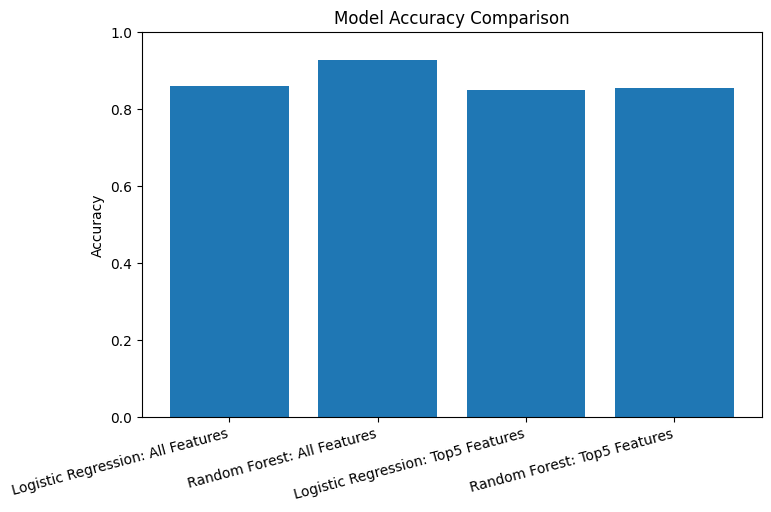

In [190]:
# Plot all model accuracies

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xticks(rotation=15, ha='right')
plt.title('Model Accuracy Comparison')
plt.show()

### Interpretation and Discussion

#### 1. Model Performance Report
Based on the experimental results, the accuracy values for the trained models are as follows:

| Model Algorithm | Version | Accuracy | Precision | Recall | F1 Score |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | Model 1: All Features | **86.05%** | 0.7648 | 0.5356 | 0.6300 |
| **Logistic Regression** | Model 2: Top 5 Features | **85.04%** | 0.7617 | 0.4734 | 0.5839 |
| **Random Forest** | Model 1: All Features | **92.86%** | 0.9430 | 0.7218 | 0.8177 |
| **Random Forest** | Model 2: Top 5 Features | **85.56%** | 0.7191 | 0.5723 | 0.6374 |


#### 2. Impact of Feature Selection on Accuracy
In both algorithms, the accuracy **decreased** when moving from the full feature set to the top 5 correlated features. 
* For **Logistic Regression**, the drop was minimal (approximately **1.01%**).
* For **Random Forest**, the drop was more significant (approximately **7.30%**).

While a decrease in accuracy is usually expected when removing data, the fact that the models retained over 85% accuracy using only five variables demonstrates that the correlation analysis successfully identified the most powerful predictors in the dataset.


#### 3. Reflection on Model Changes
The performance shift between Model 1 and Model 2 can be attributed to several factors:

* **Loss of Information:** The decrease in performance, and particularly the drop in **Recall** for Logistic Regression, suggests that while the top 5 features are the strongest, the removed features contain information that helps the model identify specific types of risky borrowers.
* **Model Complexity:** Random Forest experienced a larger performance drop because it is an ensemble method designed to find complex interactions between many variables. By restricting it to only 5 features, we limited its ability to build the diverse, high-dimensional trees that typically give it an edge over linear models.
* **Improved Generalization:** However, the models using only the top 5 are simpler. While their accuracy is lower, they are less likely to overfit, making it potentially more robust when applied to unseen datasets.

#### 4. Conclusion: Key Factors in Credit Risk

Based on the correlation analysis and model performance, the most critical factors affecting credit risk in this dataset are:

1. **Loan-to-Income Ratio (`loan_percent_income`):** This was the strongest predictor, confirming that a borrower’s financial burden relative to their earnings is the primary driver of default.
2. **Interest Rate (`loan_int_rate`):** High interest rates strongly correlate with default, reflecting both the increased cost of debt for the borrower and the lender’s risk-assessment.
3. **Loan Grade (D and E):** These categorical risk buckets effectively group high-risk applicants based on historical credit behavior and internal grading systems.
4. **Housing Status (Renters):** Renting vs. owning served as a significant proxy for financial stability and asset ownership.

**Final Observation** 

For this credit risk task, the Random Forest model using all features provided the best overall performance (92.86% accuracy and 0.8177 F1 Score), making it the most effective tool for minimizing lending risk in this context.